### notebook non utilisé dans la version finale. Je l'ai gardé car il propose des analyses du dataset non ré-implémentée dans la version finale, qui ont permis de s'assurer de la bonne qualité de la donnée.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import folium
from folium.plugins import MarkerCluster
import geopandas as gpd

import requests
import json

from shapely.geometry import Point, shape
from shapely.ops import unary_union
from geopy.distance import geodesic # Pour un calcul précis en mètres

import seaborn as sns

In [ ]:
file_path = '/Users/quentingirard/Downloads/MCNDU_simple_clean_full_dataset - only bad datapoints cleaned.csv'

try:
    full_df_clean = pd.read_csv(file_path, sep=';', encoding='utf-8')
    
    full_df_clean['Datetime'] = pd.to_datetime(full_df_clean['Datetime'])
    
    print("✅ Importation réussie avec le séparateur ';' !")
    print(f"Dimensions : {full_df_clean.shape[0]} lignes, {full_df_clean.shape[1]} colonnes.")
    display(full_df_clean.head())

except Exception as e:
    print(f"❌ Erreur lors de l'importation : {e}")

✅ Importation réussie avec le séparateur ';' !
Dimensions : 12203672 lignes, 15 colonnes.


,Occupation,Debit,Arc Name,Arc ID,Datetime,End Date Available Data,Start Date Available Data,ID Upstream Node,Trafic,ID Downstream Node,Upstream Node Name,Arc State,Downstream Node Name,Latitude,Longitude
0,3.14333,425.0,Bd_Poniatowski,6997,2026-01-05 15:00:00+00:00,2023-01-01,2016-09-15,3627,Fluide,565,Poniatowski-Baron-Leroy,1.0,Bd_Poniatowski-Pte_Charenton,48.831201,2.396694
1,6.77778,569.0,Bd_Malesherbes,239,2026-01-05 15:00:00+00:00,2023-01-01,1996-10-03,144,Fluide,146,Bd_Malesherbes-Chauveau_Lagarde,1.0,Bd_Malesherbes-Boissy_d'Anglas,48.871119,2.322386
2,2.77555,153.0,Bd_Jourdan,726,2026-01-05 15:00:00+00:00,2023-01-01,1996-10-03,416,Fluide,422,Pl_25_Aout_1944-Av_Gal_Leclerc,1.0,Bd_Jourdan-Pere_Corentin,48.822973,2.326119
3,4.45778,598.0,Bd_Brune,724,2026-01-05 15:00:00+00:00,2019-06-01,2005-01-01,411,Fluide,412,Pl_Pte_Chatillon,1.0,Bd_Brune-Av_Pte_Montrouge,48.823857,2.322154
4,4.43278,598.0,Bd_Brune,723,2026-01-05 15:00:00+00:00,2023-01-01,1996-10-03,407,Fluide,411,Bd_Brune-Plantes,1.0,Pl_Pte_Chatillon,48.824657,2.318709


In [ ]:
# DROPPING ROWS WITH MISSING COORDINATES 

total_initial = len(full_df_clean)

full_df_clean = full_df_clean.dropna(subset=['Latitude', 'Longitude'])

total_final = len(full_df_clean)
lignes_drop = total_initial - total_final

print(f"--- NETTOYAGE DES COORDONNÉES ---")
print(f"Lignes supprimées (NaN) : {lignes_drop}")
print(f"Lignes restantes        : {total_final}")
print(f"Pourcentage conservé    : {(total_final/total_initial)*100:.2f}%")

--- NETTOYAGE DES COORDONNÉES ---
Lignes supprimées (NaN) : 11411744
Lignes restantes        : 791928
Pourcentage conservé    : 6.49%


## Time-Range and Location Analysis

**STEP 1:** We make sure the data flow is continuous over time (same number of datapoints per day)

Statistiques des entrées par jour (Excluant le 2026-01-05) :
--------------------------------------------------
Maximum      : 31442.00
Minimum      : 1127.00
Moyenne      : 28071.80
Médiane      : 29262.00
Écart-type   : 4520.72
--------------------------------------------------


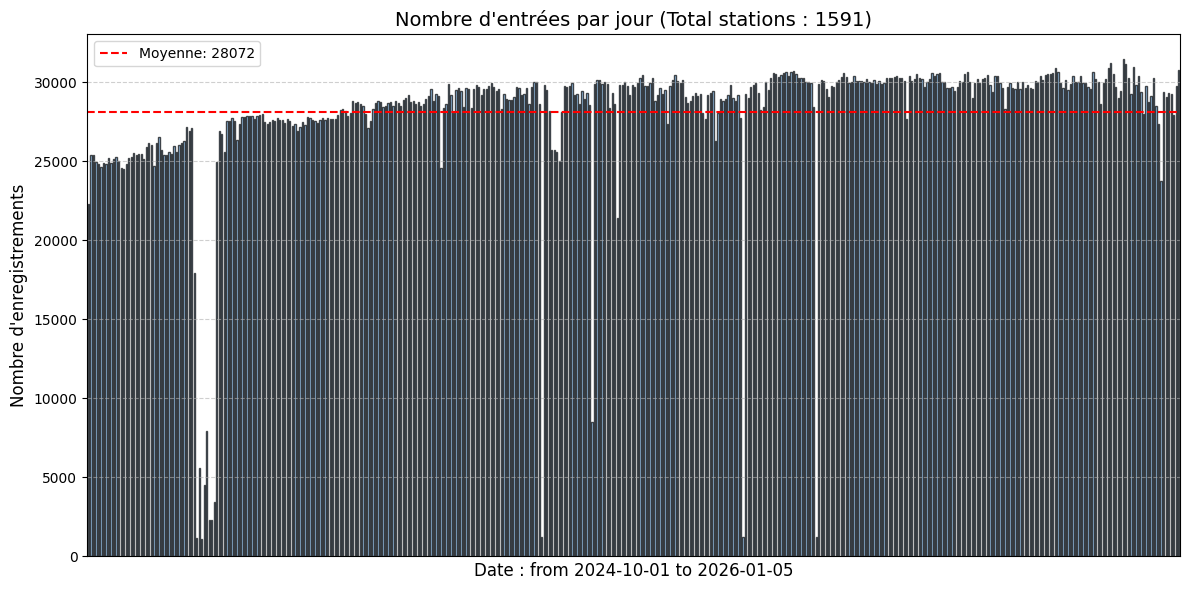

In [ ]:
# Date extraction
full_df_clean['Date_Only'] = full_df_clean['Datetime'].dt.date

# Excluding the most recent day (potentially incomplete)
last_day = full_df_clean['Date_Only'].max()
df_final_plot = full_df_clean[full_df_clean['Date_Only'] < last_day]

daily_counts = df_final_plot.groupby('Date_Only').size()

stats = {
    "Maximum": daily_counts.max(),
    "Minimum": daily_counts.min(),
    "Moyenne": daily_counts.mean(),
    "Médiane": daily_counts.median(),
    "Écart-type": daily_counts.std()
}

print(f"Statistiques des entrées par jour (Excluant le {last_day}) :")
print("-" * 50)
for key, value in stats.items():
    print(f"{key:12} : {value:.2f}")
print("-" * 50)

# Plotting 
plt.figure(figsize=(12, 6))
daily_counts.plot(kind='bar', color="#7bb7ef", edgecolor='black', alpha=0.7)

plt.axhline(stats["Moyenne"], color='red', linestyle='--', label=f'Moyenne: {stats["Moyenne"]:.0f}')
plt.title(f"Nombre d'entrées par jour (Total stations : {full_df_clean['Arc ID'].nunique()})", fontsize=14)
plt.xlabel(f"Date : from {full_df_clean['Date_Only'].min()} to {last_day}", fontsize=12)
plt.ylabel("Nombre d'enregistrements", fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

/var/folders/gl/j4h6g1555f7669vb8m7321jc0000gn/T/ipykernel_86716/1385699641.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_counts = full_df_clean['Datetime'].dt.to_period('M').value_counts().sort_index()


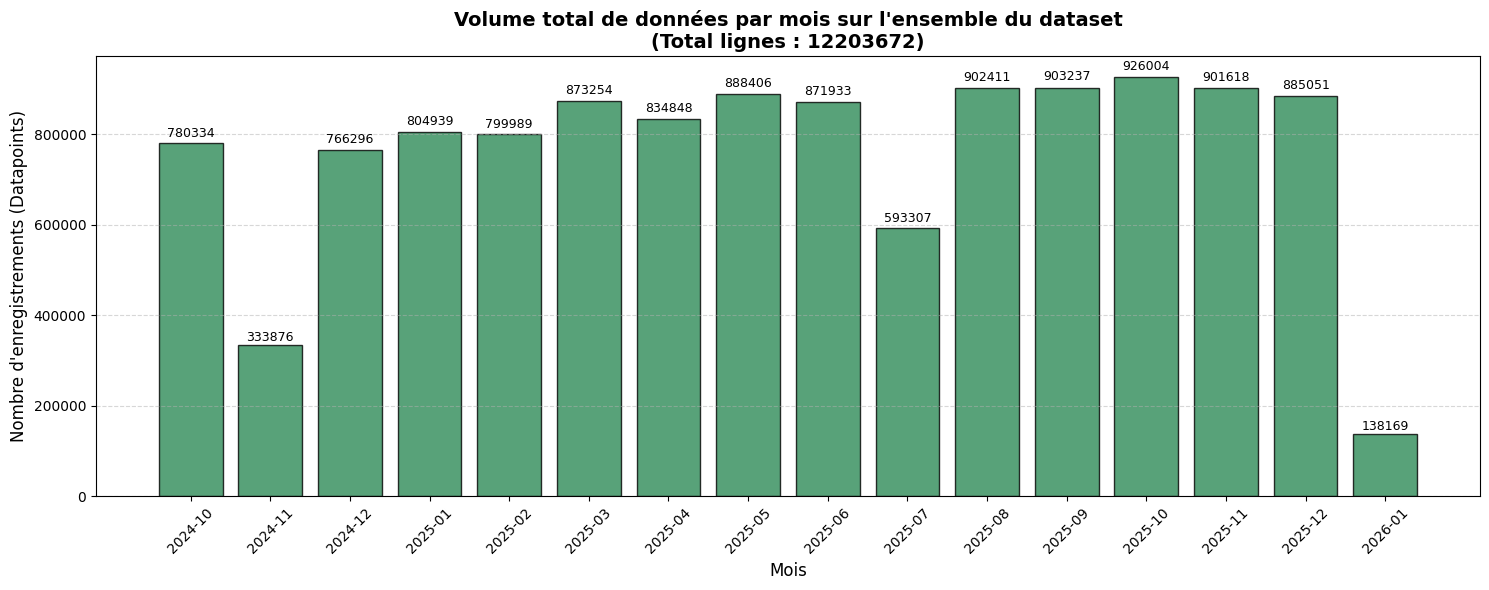

In [ ]:
# PRÉPARATION DES DONNÉES 

full_df_clean['Datetime'] = pd.to_datetime(full_df_clean['Datetime'])

monthly_counts = full_df_clean['Datetime'].dt.to_period('M').value_counts().sort_index()


plt.figure(figsize=(15, 6))

plt.bar(monthly_counts.index.astype(str), monthly_counts.values, color='#2E8B57', edgecolor='black', alpha=0.8)

plt.title(f"Volume total de données par mois sur l'ensemble du dataset\n(Total lignes : {len(full_df_clean)})", fontsize=14, fontweight='bold')
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Nombre d'enregistrements (Datapoints)", fontsize=12)
plt.xticks(rotation=45) # Rotation des dates pour lisibilité
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(monthly_counts.values):
    plt.text(i, v + (v*0.01), str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Data seems continuous over time.

**STEP 2**: Make sure the data is located evenly in all Paris

✅ Géométrie chargée pour 20 arrondissements.
Aperçu des données par arrondissement :


,Arrondissement,Volume_Donnees,Nb_Stations,Moyenne_Points_Par_Station
0,1,13658,23,593.826087
1,2,10625,18,590.277778
2,3,7625,14,544.642857
3,4,23703,40,592.575000
4,5,26949,49,549.979592


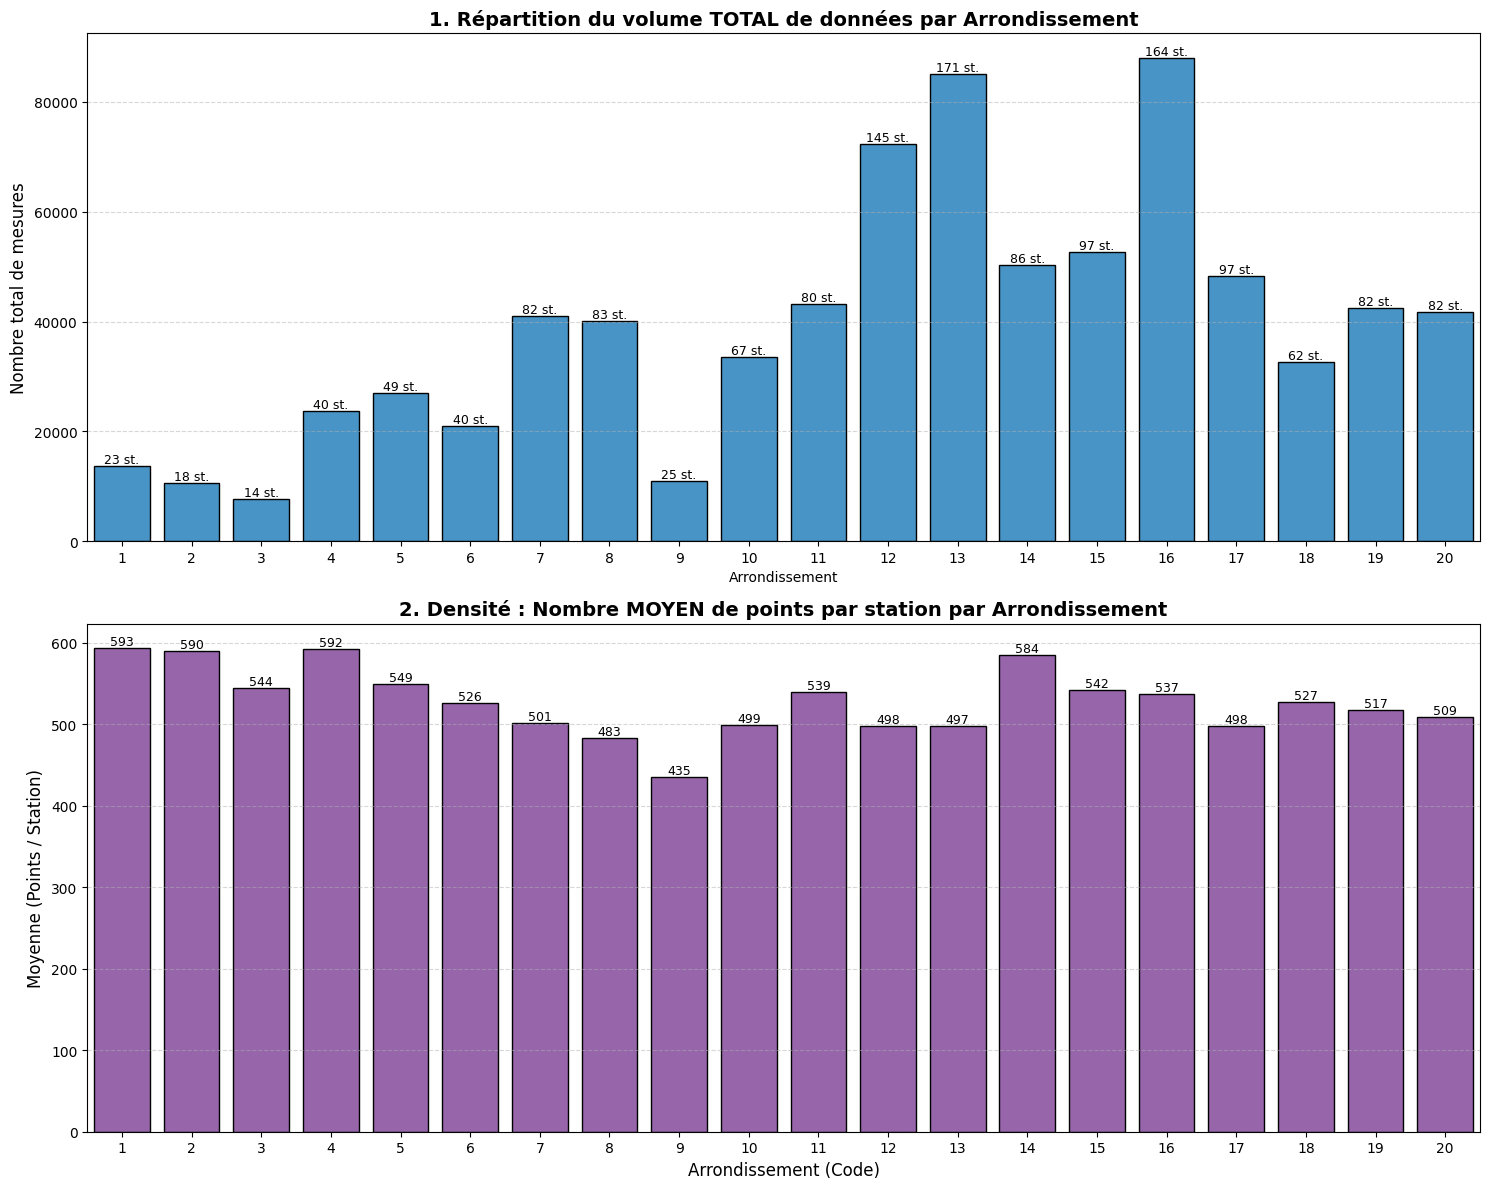

In [ ]:
url_geojson = "https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/arrondissements/exports/geojson?lang=fr&timezone=Europe%2FParis"
geo_data_all = requests.get(url_geojson).json()

arrondissements_shapes = {}
for feature in geo_data_all['features']:
    code_arr = feature['properties']['c_ar']
    arrondissements_shapes[code_arr] = shape(feature['geometry'])

print(f"✅ Géométrie chargée pour {len(arrondissements_shapes)} arrondissements.")


unique_stations = full_df_clean[['Latitude', 'Longitude']].drop_duplicates().copy()

def trouver_arrondissement(row):
    point = Point(row['Longitude'], row['Latitude'])
    for code, polygon in arrondissements_shapes.items():
        if polygon.contains(point):
            return code
    return None

unique_stations['Arrondissement'] = unique_stations.apply(trouver_arrondissement, axis=1)

df_with_arr = full_df_clean.merge(
    unique_stations, 
    on=['Latitude', 'Longitude'], 
    how='left'
)

stats_arr = df_with_arr.groupby('Arrondissement').size().reset_index(name='Volume_Donnees')
stats_arr['Arrondissement'] = stats_arr['Arrondissement'].astype(int)

stations_count = unique_stations.groupby('Arrondissement').size().reset_index(name='Nb_Stations')

stats_arr = stats_arr.merge(stations_count, on='Arrondissement')

stats_arr['Moyenne_Points_Par_Station'] = stats_arr['Volume_Donnees'] / stats_arr['Nb_Stations']

stats_arr = stats_arr.sort_values('Arrondissement')
print("Aperçu des données par arrondissement :")
display(stats_arr.head())


# plotting histograms

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

sns.barplot(data=stats_arr, x='Arrondissement', y='Volume_Donnees', color='#3498db', edgecolor='black', ax=axes[0])
axes[0].set_title("1. Répartition du volume TOTAL de données par Arrondissement", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Nombre total de mesures", fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for i, (idx, row) in enumerate(stats_arr.iterrows()):
    axes[0].text(
        x=i, 
        y=row['Volume_Donnees'], 
        s=f"{int(row['Nb_Stations'])} st.", 
        ha='center', va='bottom', fontsize=9, color='black'
    )

sns.barplot(data=stats_arr, x='Arrondissement', y='Moyenne_Points_Par_Station', color='#9b59b6', edgecolor='black', ax=axes[1])
axes[1].set_title("2. Densité : Nombre MOYEN de points par station par Arrondissement", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Moyenne (Points / Station)", fontsize=12)
axes[1].set_xlabel("Arrondissement (Code)", fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for i, (idx, row) in enumerate(stats_arr.iterrows()):
    val = row['Moyenne_Points_Par_Station']
    axes[1].text(
        x=i, 
        y=val, 
        s=f"{int(val)}", 
        ha='center', va='bottom', fontsize=9, color='black'
    )

plt.tight_layout()
plt.show()


# plotting map

m_moyenne = folium.Map(location=[48.8566, 2.3522], zoom_start=12, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=geo_data_all,
    name="Moyenne points/station",
    data=stats_arr,
    columns=['Arrondissement', 'Moyenne_Points_Par_Station'], # On utilise la nouvelle colonne
    key_on='feature.properties.c_ar',
    fill_color='Purples', 
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Moyenne de points de données par station'
).add_to(m_moyenne)

folium.GeoJson(
    geo_data_all,
    style_function=lambda x: {'fillColor': '#00000000', 'color': '#00000000'},
    tooltip=folium.GeoJsonTooltip(
        fields=['l_ar'],
        aliases=['Arrondissement:'],
        labels=True,
        sticky=True
    )
).add_to(m_moyenne)

m_moyenne

The result is good : some districts have less datapoints than others but that's because there are less stations. There is the same density of data per station everywhere. 

**STEP 3:** Map check : datapoints must be everywhere in Paris and we must not have any large zone without any data
We also plot on the map the connexion points between highways and Boulvard Périphérique, and the Zone a Trafic Limité.

In [ ]:
def visualiser_historique_arrondissement(numero_arrondissement, dataframe=df_with_arr):
    """
    Trace l'histogramme du volume de données par mois pour un arrondissement donné.
    """
    
    # filtre sur l'arrondissement spécifique
    subset_arr = dataframe[dataframe['Arrondissement'] == numero_arrondissement].copy()
    
    if subset_arr.empty:
        print(f"Aucune donnée trouvée pour l'arrondissement {numero_arrondissement}.")
        return
        
    monthly_counts = subset_arr['Datetime'].dt.to_period('M').value_counts().sort_index()
    
    total_lignes = len(subset_arr)
    nb_stations = subset_arr.groupby(['Latitude', 'Longitude']).ngroups

    # plotting
    plt.figure(figsize=(15, 6))

    plt.bar(
        monthly_counts.index.astype(str), 
        monthly_counts.values, 
        color='#008B8B',
        edgecolor='black', 
        alpha=0.8
    )

    plt.title(
        f"Historique des données : {numero_arrondissement}e Arrondissement de Paris\n"
        f"(Total : {total_lignes} mesures sur {nb_stations} stations)", 
        fontsize=14, fontweight='bold', color='#008B8B'
    )
    plt.xlabel("Mois", fontsize=12)
    plt.ylabel("Nombre d'enregistrements", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for i, v in enumerate(monthly_counts.values):
        plt.text(i, v + (v*0.01), str(v), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

visualiser_historique_arrondissement(4)

KeyError: 'Arrondissement'

In [ ]:
#plotting the ZTL in the map
url_geojson = "https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/arrondissements/exports/geojson?lang=fr&timezone=Europe%2FParis"
response = requests.get(url_geojson)
geo_data = response.json()

# keeping arr 1, 2, 3 et 4
paris_centre_features = [
    feature for feature in geo_data['features'] 
    if feature['properties']['c_ar'] in [1, 2, 3, 4]
]

paris_centre_geojson = {
    "type": "FeatureCollection",
    "features": paris_centre_features
}

location_data = full_df_clean.groupby(['Latitude', 'Longitude']).size().reset_index(name='counts')

# Map plotting
center_lat = location_data['Latitude'].mean()
center_lon = location_data['Longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='CartoDB positron') 

# adding stations
for index, row in location_data.iterrows():
    
    radius_size = row['counts'] / 100
    
    if radius_size < 3:
        radius_size = 3

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=radius_size,
        popup=f"Volume: {row['counts']}", 
        tooltip=f"Area: {row['counts']} measurements", 
        color='#FF4500',      
        fill=True,
        fill_color='#FF4500', 
        fill_opacity=0.6    
    ).add_to(m)


# ajout points d'insertion autoroutes

autoroutes_coords = {
    'A1 (Porte de la Chapelle)': [48.9004, 2.3596],
    'A3 (Porte de Bagnolet)': [48.8687, 2.4105],
    'A4 (Porte de Bercy)': [48.8324, 2.3861],
    'A6a (Porte d\'Orléans)': [48.8208, 2.3259],
    'A6b (Porte d\'Italie)': [48.8159, 2.3603],
    'A13 (Porte d\'Auteuil)': [48.8465, 2.2547]
}

for name, coords in autoroutes_coords.items():
    folium.CircleMarker(
        location=coords,
        radius=8,            
        popup=name,         
        tooltip=name,       
        color='blue',        
        fill=True,
        fill_color='blue',  
        fill_opacity=1.0, 
        weight=2   
    ).add_to(m)

# Plotting the ZTL

folium.GeoJson(
    paris_centre_geojson,
    name="Paris Centre (ZTL)",
    style_function=lambda x: {
        'fillColor': '#FFD700',
        'color': '#FFD700',    
        'weight': 3,          
        'fillOpacity': 0.2  
    },
    tooltip="Paris Centre (Arr. 1-4)"
).add_to(m)

m

**Conclusion :** No big white zone, data everywhere, data in the zones of interest -> we're happy. 

## Points inside and near Zone à Traffic Limité

**STEP 1** : Creating one sub-dataset of points inside the ZTL + one sub-dataset for points around the ZTL. 

In [ ]:
# sous dataset ZTL

print("Construction de la géométrie ZTL et filtrage des données...")

ztl_polygons = [shape(feature['geometry']) for feature in paris_centre_features]
ztl_boundary = unary_union(ztl_polygons)

unique_stations = full_df_clean[['Latitude', 'Longitude']].drop_duplicates()

def is_in_ztl(row):
    point = Point(row['Longitude'], row['Latitude'])
    return ztl_boundary.contains(point)

unique_stations['is_inside'] = unique_stations.apply(is_in_ztl, axis=1)

valid_stations = unique_stations[unique_stations['is_inside'] == True]

ZTL_dataset = full_df_clean.merge(
    valid_stations[['Latitude', 'Longitude']], 
    on=['Latitude', 'Longitude'], 
    how='inner'
)

# results
print("-" * 30)
print("✅ Dataset ZTL créé avec succès.")
print(f"Nombre de mesures dans la ZTL : {len(ZTL_dataset)}")
print(f"Nombre de stations de comptage uniques dans la ZTL : {len(valid_stations)}")
print("-" * 30)

Construction de la géométrie ZTL et filtrage des données...
------------------------------
✅ Dataset ZTL créé avec succès.
Nombre de mesures dans la ZTL : 55611
Nombre de stations de comptage uniques dans la ZTL : 95
------------------------------


In [ ]:
# création du buffer autour de la ZTL

distance_buffer_meters = 500

gdf_ztl = gpd.GeoDataFrame.from_features(paris_centre_features)
gdf_ztl = gdf_ztl.set_crs(epsg=4326) # On précise que c'est du GPS (WGS84)

gdf_ztl_union = gdf_ztl.dissolve()

gdf_buffer = gdf_ztl_union.to_crs(epsg=2154).buffer(distance_buffer_meters).to_crs(epsg=4326)

gdf_ring = gdf_buffer.difference(gdf_ztl_union)

In [ ]:
# creation dataset buffer autour de la ZTL
ring_geometry = gdf_ring.unary_union

unique_stations = full_df_clean[['Latitude', 'Longitude']].drop_duplicates()

def is_in_ring(row):
    point = Point(row['Longitude'], row['Latitude'])
    return ring_geometry.contains(point)

print(f"Filtrage des stations situées dans l'anneau de {distance_buffer_meters}m...")

unique_stations_ring = unique_stations.copy()
unique_stations_ring['in_ring'] = unique_stations_ring.apply(is_in_ring, axis=1)

valid_stations_ring = unique_stations_ring[unique_stations_ring['in_ring'] == True]

around_ZTL_dataset = full_df_clean.merge(
    valid_stations_ring[['Latitude', 'Longitude']], 
    on=['Latitude', 'Longitude'], 
    how='inner'
)

print("-" * 30)
print(f"✅ Dataset 'around_ZTL' créé (Buffer: {distance_buffer_meters}m).")
print(f"Nombre de mesures dans l'anneau : {len(around_ZTL_dataset)}")
print(f"Nombre de stations uniques dans l'anneau : {len(valid_stations_ring)}")
print("-" * 30)

/var/folders/gl/j4h6g1555f7669vb8m7321jc0000gn/T/ipykernel_86716/3105591425.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ring_geometry = gdf_ring.unary_union


Filtrage des stations situées dans l'anneau de 500m...
------------------------------
✅ Dataset 'around_ZTL' créé (Buffer: 500m).
Nombre de mesures dans l'anneau : 86401
Nombre de stations uniques dans l'anneau : 164
------------------------------


**STEP 2:** Verification on a map

In [ ]:
# Ploting on map
ztl_location_data = ZTL_dataset.groupby(['Latitude', 'Longitude']).size().reset_index(name='counts')
around_ztl_location_data = around_ZTL_dataset.groupby(['Latitude', 'Longitude']).size().reset_index(name='counts')

if not ztl_location_data.empty:
    center_lat = ztl_location_data['Latitude'].mean()
    center_lon = ztl_location_data['Longitude'].mean()
else:
    center_lat, center_lon = 48.8566, 2.3522

m_ztl = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles='CartoDB positron')

for index, row in ztl_location_data.iterrows():
    
    radius_size = row['counts'] / 100
    if radius_size < 4: 
        radius_size = 4

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=radius_size,
        popup=f"Station ZTL<br>Volume: {row['counts']}",
        tooltip=f"Mesures: {row['counts']}",
        color='#FF4500',     
        fill=True,
        fill_color='#FF4500',
        fill_opacity=0.7
    ).add_to(m_ztl)

# ajout des stations dans le buffer
for index, row in around_ztl_location_data.iterrows():
    radius_size = row['counts'] / 100
    if radius_size < 4: radius_size = 4

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=radius_size,
        popup=f"<b>Station Anneau (Contournement)</b><br>Volume: {row['counts']}",
        tooltip=f"Ring: {row['counts']} mesures",
        color='#4B0082',   
        fill=True,
        fill_color='#4B0082', 
        fill_opacity=0.7
    ).add_to(m_ztl)

# tracé de la ZTL
folium.GeoJson(
    paris_centre_geojson,
    name="Paris Centre (ZTL)",
    style_function=lambda x: {
        'fillColor': '#FFD700', 
        'color': '#FFD700',    
        'weight': 3,     
        'fillOpacity': 0.2  
    },
    tooltip="Zone à Trafic Limité (Arr. 1-4)"
).add_to(m_ztl)

# Tracé du buffer

folium.GeoJson(
    gdf_ring,
    name="Zone Tampon",
    style_function=lambda x: {
        'fillColor': '#FF1493',   # Rose foncé (DeepPink)
        'color': '#C71585',       # Contour assorti
        'weight': 2,
        'fillOpacity': 0.4        # Transparence pour voir les rues dessous
    },
    tooltip="Zone d'étude contournement de la ZTL"
).add_to(m_ztl)

print(f"Affichage de {len(ztl_location_data)} stations de comptage dans la ZTL.")
m_ztl

Affichage de 95 stations de comptage dans la ZTL.


**STEP 3 :** Checking there are enough datapoints inside the ZTL and outside the ZTL.

--- STATISTIQUES ZTL (Intérieur) ---
Nombre de stations : 95
Moyenne de points par station : 585.38
Minimum de points : 284
Maximum de points : 626

------------------------------

--- STATISTIQUES ANNEAU (Autour) ---
Nombre de stations : 164
Moyenne de points par station : 526.84
Minimum de points : 43
Maximum de points : 628


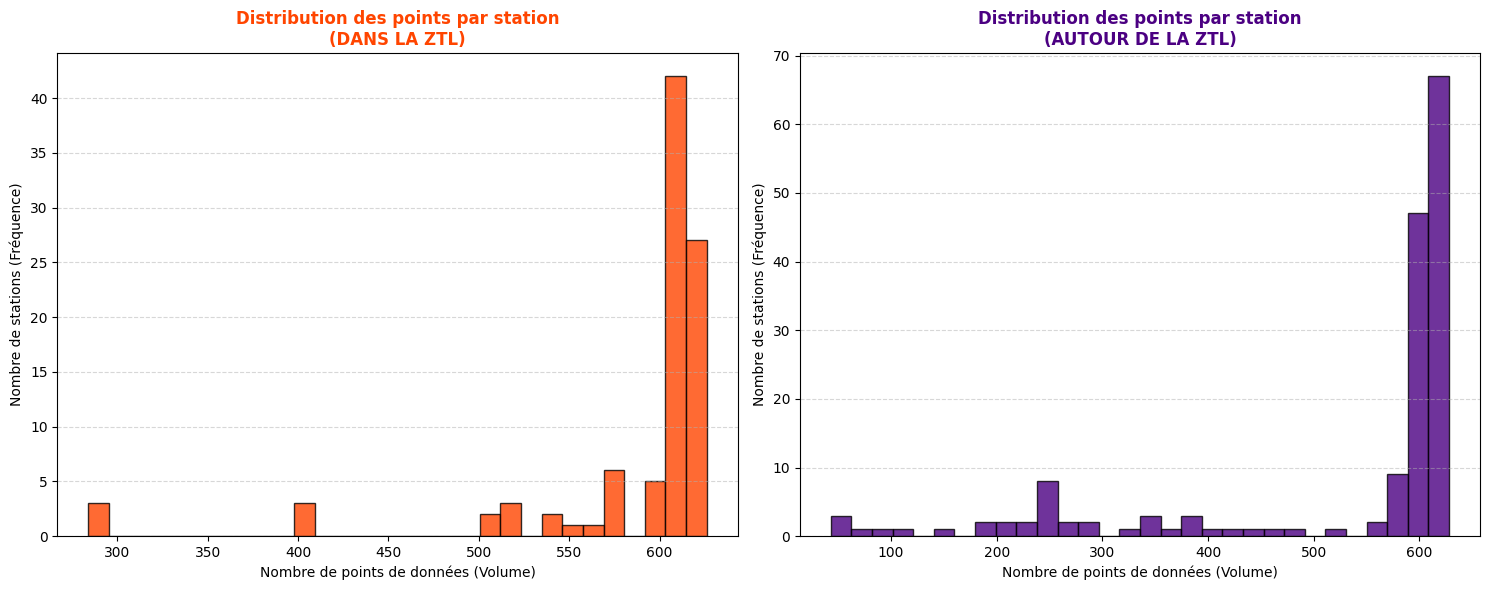

In [ ]:
# datapoints per station analysis

counts_per_station_ztl = ZTL_dataset.groupby(['Latitude', 'Longitude']).size()

counts_per_station_around = around_ZTL_dataset.groupby(['Latitude', 'Longitude']).size()

print(f"--- STATISTIQUES ZTL (Intérieur) ---")
print(f"Nombre de stations : {len(counts_per_station_ztl)}")
print(f"Moyenne de points par station : {counts_per_station_ztl.mean():.2f}")
print(f"Minimum de points : {counts_per_station_ztl.min()}")
print(f"Maximum de points : {counts_per_station_ztl.max()}")
print("\n" + "-"*30 + "\n")
print(f"--- STATISTIQUES ANNEAU (Autour) ---")
print(f"Nombre de stations : {len(counts_per_station_around)}")
print(f"Moyenne de points par station : {counts_per_station_around.mean():.2f}")
if not counts_per_station_around.empty:
    print(f"Minimum de points : {counts_per_station_around.min()}")
    print(f"Maximum de points : {counts_per_station_around.max()}")


# histogram plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

# Histogramme 1 : ZTL
axes[0].hist(counts_per_station_ztl, bins=30, color='#FF4500', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution des points par station\n(DANS LA ZTL)', fontsize=12, fontweight='bold', color='#FF4500')
axes[0].set_xlabel('Nombre de points de données (Volume)')
axes[0].set_ylabel('Nombre de stations (Fréquence)')
axes[0].grid(axis='y', alpha=0.5, linestyle='--')

# Histogramme 2 : Autour ZTL
axes[1].hist(counts_per_station_around, bins=30, color='#4B0082', edgecolor='black', alpha=0.8)
axes[1].set_title('Distribution des points par station\n(AUTOUR DE LA ZTL)', fontsize=12, fontweight='bold', color='#4B0082')
axes[1].set_xlabel('Nombre de points de données (Volume)')
axes[1].set_ylabel('Nombre de stations (Fréquence)')
axes[1].grid(axis='y', alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

--- Recherche dans ZTL (Intérieur) ---
Nombre de stations candidates (entre 610 et 620 pts) : 46
📍 Station choisie : Lat 48.850269640721194, Lon 2.3614313694927636 (620 points)


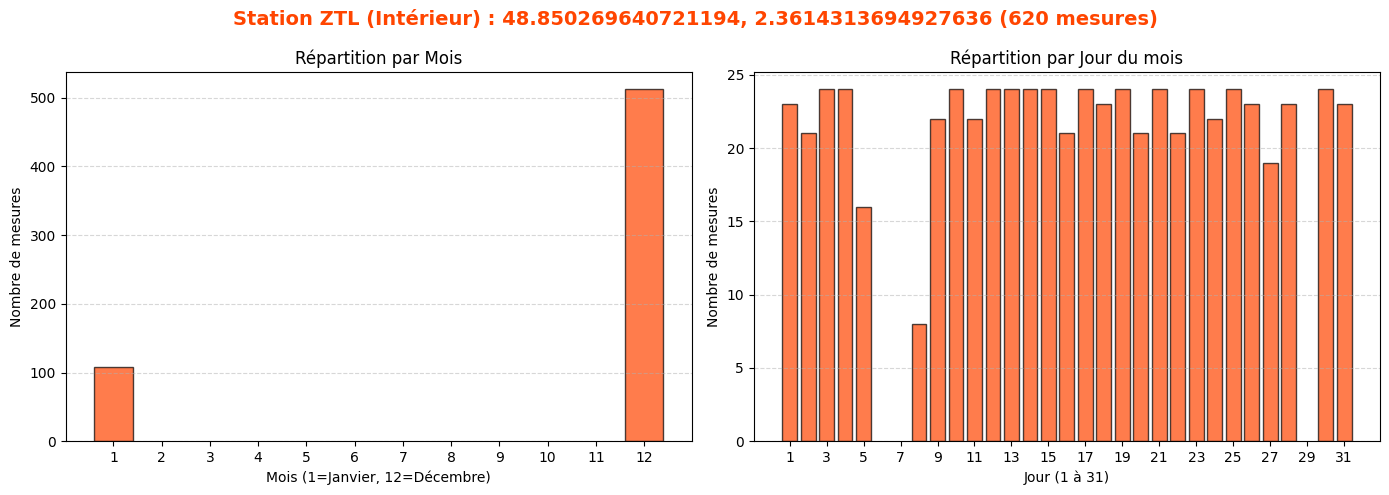

--- Recherche dans ZONE TAMPON (Autour) ---
Nombre de stations candidates (entre 610 et 620 pts) : 45
📍 Station choisie : Lat 48.86990107538952, Lon 2.3517127975570995 (619 points)


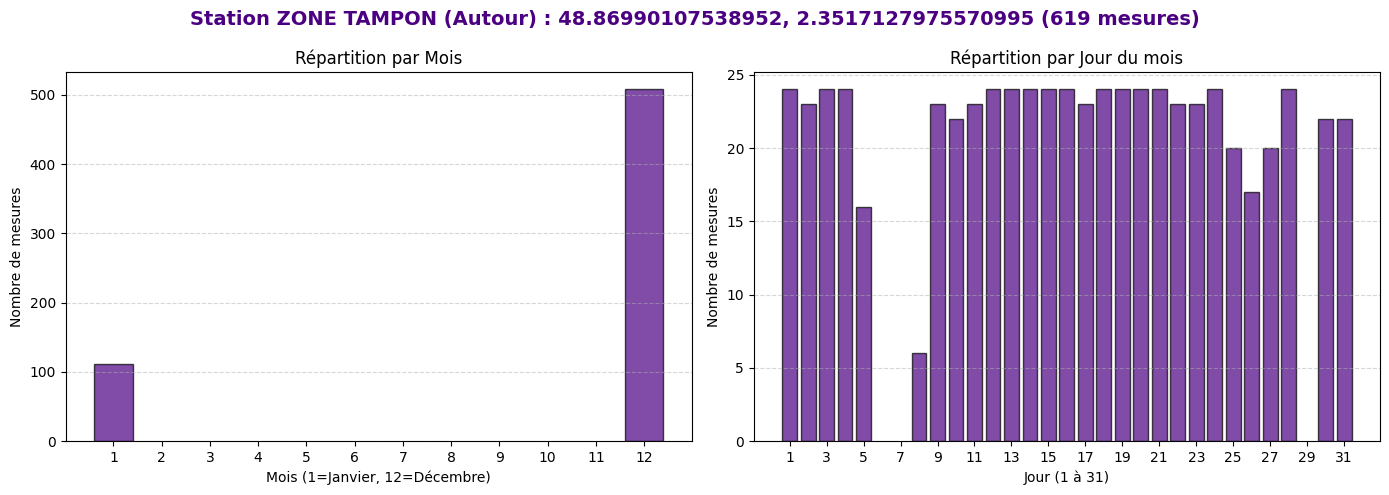

In [ ]:
def analyser_station_aleatoire(dataset, nom_zone, couleur, min_pts=610, max_pts=620):
    """
    Choisit une station au hasard avec un nombre de points entre min_pts et max_pts,
    puis affiche la répartition temporelle.
    """
    
    stats_stations = dataset.groupby(['Latitude', 'Longitude']).size()
    
    candidats = stats_stations[
        (stats_stations >= min_pts) & 
        (stats_stations <= max_pts)
    ]
    
    print(f"--- Recherche dans {nom_zone} ---")
    print(f"Nombre de stations candidates (entre {min_pts} et {max_pts} pts) : {len(candidats)}")
    
    if candidats.empty:
        print(f"Aucune station trouvée dans cette plage pour {nom_zone}. Essayez d'élargir x et y.")
        return

    station_choisie = candidats.sample(1).index[0]
    lat, lon = station_choisie
    n_points = candidats.loc[station_choisie]
    
    print(f" Station choisie : Lat {lat}, Lon {lon} ({n_points} points)")
    
    df_station = dataset[
        (dataset['Latitude'] == lat) & 
        (dataset['Longitude'] == lon)
    ].copy()
    
    df_station['Datetime'] = pd.to_datetime(df_station['Datetime'])
    
    df_station['Mois'] = df_station['Datetime'].dt.month
    df_station['Jour'] = df_station['Datetime'].dt.day
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Station {nom_zone} : {lat}, {lon} ({n_points} mesures)", fontsize=14, color=couleur, fontweight='bold')
    
    # Histogramme par MOIS
    counts_mois = df_station['Mois'].value_counts().sort_index()
    axes[0].bar(counts_mois.index, counts_mois.values, color=couleur, alpha=0.7, edgecolor='black')
    axes[0].set_title("Répartition par Mois")
    axes[0].set_xlabel("Mois (1=Janvier, 12=Décembre)")
    axes[0].set_ylabel("Nombre de mesures")
    axes[0].set_xticks(range(1, 13)) # Force l'affichage de 1 à 12
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)
    
    # Histogramme par JOUR
    counts_jours = df_station['Jour'].value_counts().sort_index()
    axes[1].bar(counts_jours.index, counts_jours.values, color=couleur, alpha=0.7, edgecolor='black')
    axes[1].set_title("Répartition par Jour du mois")
    axes[1].set_xlabel("Jour (1 à 31)")
    axes[1].set_ylabel("Nombre de mesures")
    axes[1].set_xticks(range(1, 32, 2)) # Un jour sur deux pour la lisibilité
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


x = 610
y = 620

# 1. Analyse pour la ZTL
analyser_station_aleatoire(
    ZTL_dataset, 
    nom_zone="ZTL (Intérieur)", 
    couleur='#FF4500',
    min_pts=x, 
    max_pts=y
)

# 2. Analyse pour la zone Autour)
analyser_station_aleatoire(
    around_ZTL_dataset, 
    nom_zone="ZONE TAMPON (Autour)", 
    couleur='#4B0082',
    min_pts=x, 
    max_pts=y
)

**ANALYSE :** On a des points de données avec **peu de données** (600 mesures par station en moyenne) et avec des stations **mal réparties**, toutes les mesures sont en décembre.

**CONCLUSION** : Les points de données semblent mal répartis spatiallement. On confirme cette hypothèse avec la représentation du nombre de datapoints dans full_df_clean par arrondissement de Paris. 

**APRES-COUP :** Je me suis rendu compte que c'était dû à la manière dont on extrayait les latitudes longitudes du dataset historique. La méthode était adaptée au dataset API mais pas au dataset historique, donc le code était incapable de les localiser.